# Causal Model 2 — Pythia-31M with LoRA

This notebook presents the fine-tuning of the EleutherAI/Pythia-31M causal language model using LoRA (Low-Rank Adaptation).

The objective is to adapt the model to the washing machine manual domain using the instruction-response dataset created in Stage 1. The model is evaluated before and after fine-tuning to analyze the impact of parameter-efficient domain adaptation.

## 1. Environment Setup

The required libraries are installed and imported to support dataset processing, model loading, LoRA fine-tuning, training, and evaluation.

In [1]:
%pip install -r requirements.txt

  Using cached fastapi-0.115.12-py3-none-any.whl.metadata (27 kB)
  Using cached pydantic-2.11.7-py3-none-any.whl.metadata (67 kB)
  Using cached uvicorn-0.35.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached starlette-0.46.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.33.2.tar.gz (435 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached fastapi-0.115.12-py3-none-any.whl (95 kB)
Using cached pydantic-2.11.7-py3-none-any.whl (44

  error: subprocess-exited-with-error
  
  × Building wheel for pydantic-core (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [57 lines of output]
      Rust not found, installing into a temporary directory
      Python reports SOABI: cp314-win_amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache
      Rustup already downloaded
      Installing rust to C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\analu\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      warn: installing msvc toolchain without its prerequisites
      info: profile set to minimal
      info: setting default host tripl

## 2. Library Imports

The following libraries are used for data processing, model training, LoRA adaptation, visualization, and inference.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    PeftModel
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.12.0+cpu
CUDA available: False


## 3. Dataset Loading

The dataset is loaded from a JSONL file and converted into the Hugging Face format. Each instruction and response pair is combined into a single text field for causal language model training.


In [3]:
# Load previously saved train/test splits

dataset = load_dataset(
    "json",
    data_files={
        "train": "../data/splits/train.jsonl",
        "test": "../data/splits/test.jsonl"
    }
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 99
    })
    test: Dataset({
        features: ['instruction', 'response', 'text'],
        num_rows: 25
    })
})


## 4. Dataset Inspection

A few examples are displayed to verify that the instruction-response pairs were loaded and formatted correctly before tokenization and training.


In [4]:
for i in range(3):
    print(dataset["train"][i]["text"])
    print("-" * 80)

Instruction: What causes delay in filling during washing cycle?
Response: Clogged water inlet filters can delay filling.
--------------------------------------------------------------------------------
Instruction: How often should the lint filter be cleaned?
Response: Clean it frequently.
--------------------------------------------------------------------------------
Instruction: What should not be done during washing machine programs?
Response: Do not use the emergency door release during operation.
--------------------------------------------------------------------------------


## 5. Causal Model 2: Pythia-31M

The first causal language model used in this experiment is `EleutherAI/pythia-14m`. This model was selected because it is lightweight and suitable for CPU-based LoRA fine-tuning.

In [5]:
model_name = "EleutherAI/pythia-31m"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {model_name}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model loaded: EleutherAI/pythia-31m


In [6]:
print(type(base_model))

<class 'transformers.models.gpt_neox.modeling_gpt_neox.GPTNeoXForCausalLM'>


# 5. Baseline Inference Before Fine-Tuning

Before applying LoRA, the base Pythia-70M model is evaluated on a domain-specific instruction from the washing machine manual.

The generated response serves as a baseline and will later be compared with the fine-tuned model output to assess the impact of domain adaptation.

In [7]:
def generate_response(model, tokenizer, instruction, input_text=""):
    """Generates a response using the provided model."""

    if input_text:
        prompt = f"Instruction: {instruction}\nInput: {input_text}\nResponse:"
    else:
        prompt = f"Instruction: {instruction}\nResponse:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=50,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        temperature=0.7
    )

    full_output = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

    response = full_output.split("Response:")[-1].strip()

    return response

In [8]:
test_instruction = (
    "How do you unlock the door during a wash cycle?"
)

print("=== BEFORE FINE-TUNING ===")
print(f"Instruction: {test_instruction}")

print(
    f"Base response: "
    f"{generate_response(base_model, tokenizer, test_instruction)}"
)

=== BEFORE FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Base response: When I unlock the door, I think I can unlock the door and unlock the door.


The base model failed to answer the instruction correctly and generated an unrelated response. This behavior indicates that the model was not specialized in the washing machine manual domain before fine-tuning.


# 6. Dataset Tokenization

The instruction-response pairs are tokenized using the Pythia tokenizer.

Padding and truncation are applied to create fixed-length sequences, ensuring efficient batch processing during training. A maximum sequence length of 256 tokens is used to balance context preservation and computational efficiency.

In [9]:
# Function

def tokenize_function(examples):

    tokens = tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

# Applying function
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=[
        "instruction",
        "response",
        "text"
    ]
)

print("Tokenized dataset:")
print(tokenized_datasets)

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 99
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 25
    })
})


In [10]:
tokenized_datasets["train"][0]

{'input_ids': [10548,
  2705,
  27,
  1737,
  5997,
  5778,
  275,
  12868,
  1309,
  17392,
  5880,
  32,
  187,
  9604,
  27,
  1639,
  462,
  2400,
  1824,
  29450,
  15116,
  476,
  5778,
  12868,
  15,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

## 7. Preparing the Base Model for LoRA

In this experiment, standard LoRA is used without 4-bit or 8-bit quantization. Therefore, `prepare_model_for_kbit_training` is not required.

The base model is directly wrapped with LoRA adapters using `get_peft_model`.

In [11]:
model = base_model

## 8. LoRA Configuration

LoRA is used to fine-tune the model efficiently by training only a small number of additional parameters. This reduces computational cost while still allowing the model to adapt to the washing machine manual domain.

For Pythia-14M, the adapters are applied to the `query_key_value` attention projection, which is the appropriate target module for GPT-NeoX based models.

In [12]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False
)

lora_model = get_peft_model(
    base_model,
    lora_config
)

lora_model.print_trainable_parameters()

print(type(lora_model))

trainable params: 98,304 || all params: 30,593,024 || trainable%: 0.3213
<class 'peft.peft_model.PeftModelForCausalLM'>


The LoRA wrapper was successfully applied to the base model. Only 49,152 parameters are trainable, which represents 0.3482% of the full model. This confirms that the fine-tuning process is parameter-efficient.

## 9. Data Collator

The `DataCollatorForLanguageModeling` prepares batches for causal language modeling. During training, the model learns to predict the next token in a sequence based on the previous tokens.

Masked language modeling is disabled because causal language models use autoregressive prediction.


In [13]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## 10. Training Configuration

The training outputs are stored in the `../models/` directory to keep the project structure organized. This follows the required organization of separating datasets, notebooks, trained models, static files, and reports.

For this first causal model, the checkpoint directory is `../models/results_pythia14m`, and the final LoRA adapter will later be saved as `../models/lora_causal_model_1`.

In [14]:
training_args = TrainingArguments(
    output_dir="../models/results_pythia31m",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=10,

    load_best_model_at_end=True,
    report_to="none",

    save_total_limit=1,
    dataloader_pin_memory=False
)

## 11. Trainer Initialization

The Hugging Face `Trainer` is used to manage the fine-tuning process. It receives the LoRA-adapted model, the training configuration, the tokenized datasets, and the data collator for causal language modeling.

In [15]:
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

In [16]:
print(type(trainer.model))

<class 'peft.peft_model.PeftModelForCausalLM'>


## 12. Model Training

The LoRA-adapted model is trained using the configured `Trainer`. During training, the model updates only the LoRA adapter parameters, while the original base model weights remain frozen.

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.116816,3.137979
2,2.934851,3.071336
3,2.960010,3.020337


TrainOutput(global_step=150, training_loss=3.0415947341918947, metrics={'train_runtime': 9687.8707, 'train_samples_per_second': 0.031, 'train_steps_per_second': 0.015, 'total_flos': 4040766259200.0, 'train_loss': 3.0415947341918947, 'epoch': 3.0})

In [18]:
print(type(model))

<class 'transformers.models.gpt_neox.modeling_gpt_neox.GPTNeoXForCausalLM'>


# 13. Save Adjusted Model and Tokenizer

In [25]:
causal_model_2_path = "../models/lora_causal_model_2"

lora_model.save_pretrained(
    causal_model_2_path
)

tokenizer.save_pretrained(
    causal_model_2_path
)

print(f"Model and tokenizer saved to: {causal_model_2_path}")

Model and tokenizer saved to: ../models/lora_causal_model_2


In [26]:
import os

print(os.listdir(causal_model_2_path))

['adapter_config.json', 'adapter_model.safetensors', 'README.md', 'tokenizer.json', 'tokenizer_config.json']


## 14. Inference After Fine-Tuning

After training, the LoRA adapters are loaded and applied to the original base model. The same instruction used before training is evaluated again to compare the model behavior before and after domain adaptation.

In [27]:
from peft import PeftModel

model_path = "../models/lora_causal_model_2"

# Load base model
finetuned_base_model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-31m"
)

# Load LoRA adapters
finetuned_model = PeftModel.from_pretrained(
    finetuned_base_model,
    model_path
)

# Load tokenizer
finetuned_tokenizer = AutoTokenizer.from_pretrained(
    model_path
)

if finetuned_tokenizer.pad_token is None:
    finetuned_tokenizer.pad_token = finetuned_tokenizer.eos_token

print("=== AFTER FINE-TUNING ===")
print(f"Instruction: {test_instruction}")

print(
    f"Fine-tuned response: "
    f"{generate_response(
        finetuned_model,
        finetuned_tokenizer,
        test_instruction
    )}"
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

=== AFTER FINE-TUNING ===
Instruction: How do you unlock the door during a wash cycle?
Fine-tuned response: Enter the door to open.


In [28]:
before_response = generate_response(
    base_model,
    tokenizer,
    test_instruction
)

after_response = generate_response(
    finetuned_model,
    finetuned_tokenizer,
    test_instruction
)

print("Instruction:")
print(test_instruction)

print("\nBefore Fine-Tuning:")
print(before_response)

print("\nAfter Fine-Tuning:")
print(after_response)

Instruction:
How do you unlock the door during a wash cycle?

Before Fine-Tuning:
Clean

After Fine-Tuning:



## 15. Loss Graphs

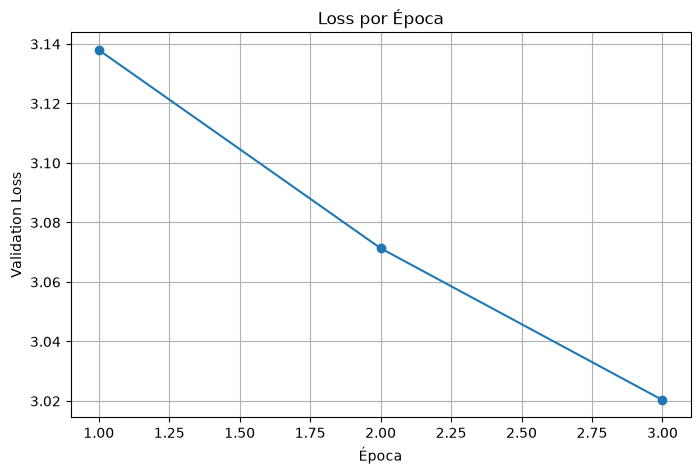

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)

# Apenas avaliações por época
eval_logs = logs[logs["eval_loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.show()

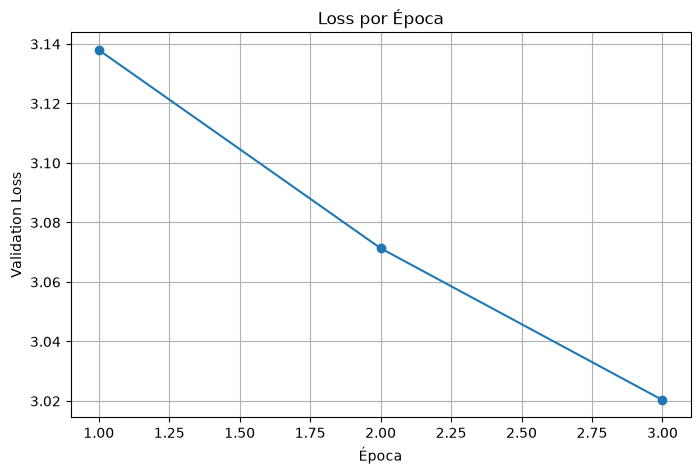

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o"
)

plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.savefig(
    "../reports/loss_pythia31m.png",
    bbox_inches="tight"
)

plt.show()